# Experiment 3 - 결측치 처리 방법 비교
실험 목적: 전체 feature(stress_level 제외) + MinMaxScaler 고정 후
결측치를 평균값으로 대체(Mean) vs 행 제거(Drop) 성능 비교

## 1. 라이브러리 임포트

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## 2. 데이터 로드 및 결측치 확인

In [3]:
data = pd.read_csv('/content/sample_data/developer_burnout_dataset_7000.csv')
print('데이터 크기:', data.shape)
print('\n결측치 현황:')
print(data.isna().sum())

데이터 크기: (7000, 12)

결측치 현황:
age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64


## 3. 타겟 라벨 인코딩

결측치 처리 전에 burnout_level 먼저 인코딩 (두 데이터셋 공통 적용)

In [4]:
data['burnout_level'].fillna(data['burnout_level'].mode()[0], inplace=True)

data['burnout_level'] = data['burnout_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
print(data['burnout_level'].value_counts())

burnout_level
1    3625
2    1782
0    1593
Name: count, dtype: int64


/tmp/ipykernel_12773/1773418135.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['burnout_level'].fillna(data['burnout_level'].mode()[0], inplace=True)


## 4. 결측치 처리 (두 가지 방법)

- **data_mean**: 수치형 결측치를 평균값으로 대체 (7000행 유지)
- **data_drop**: 결측치 있는 행 전체 제거 (행 수 감소)

In [5]:
data_mean = data.fillna(data.mean(numeric_only=True))

data_drop = data.dropna(axis=0)

print(f'평균 대체 후 shape: {data_mean.shape}')
print(f'행 제거 후 shape:   {data_drop.shape}')

평균 대체 후 shape: (7000, 12)
행 제거 후 shape:   (5606, 12)


## 5. Feature / Target 정의 및 데이터 분할

- experiment1 결과: 전체 feature(stress_level 제외) 고정
- experiment2 결과: MinMaxScaler 고정

In [6]:
feature_columns = ['age','experience_years','daily_work_hours','sleep_hours',
                   'caffeine_intake','bugs_per_day','commits_per_day',
                   'meetings_per_day','screen_time','exercise_hours']
target_column = ['burnout_level']

feature_mean = data_mean[feature_columns]
feature_drop = data_drop[feature_columns]
target_mean  = data_mean[target_column]
target_drop  = data_drop[target_column]

X_train_mn, X_test_mn, y_train_mn, y_test_mn = train_test_split(
    feature_mean, target_mean, test_size=0.2, random_state=42)

X_train_dp, X_test_dp, y_train_dp, y_test_dp = train_test_split(
    feature_drop, target_drop, test_size=0.2, random_state=42)

print(f'Mean - Train: {X_train_mn.shape} / Test: {X_test_mn.shape}')
print(f'Drop - Train: {X_train_dp.shape} / Test: {X_test_dp.shape}')

Mean - Train: (5600, 10) / Test: (1400, 10)
Drop - Train: (4484, 10) / Test: (1122, 10)


## 6. 정규화 (MinMaxScaler)

In [7]:
mm_mn = MinMaxScaler()
mm_dp = MinMaxScaler()

X_train_mn = mm_mn.fit_transform(X_train_mn)
X_test_mn  = mm_mn.transform(X_test_mn)

X_train_dp = mm_dp.fit_transform(X_train_dp)
X_test_dp  = mm_dp.transform(X_test_dp)

## 7. Tensor 변환

In [8]:
X_train_mn = torch.FloatTensor(X_train_mn)
X_test_mn  = torch.FloatTensor(X_test_mn)
X_train_dp = torch.FloatTensor(X_train_dp)
X_test_dp  = torch.FloatTensor(X_test_dp)

y_train_mn = torch.LongTensor(y_train_mn.values)
y_test_mn  = torch.LongTensor(y_test_mn.values)
y_train_dp = torch.LongTensor(y_train_dp.values)
y_test_dp  = torch.LongTensor(y_test_dp.values)

## 8. DataLoader

In [9]:
train_loader_mn = DataLoader(TensorDataset(X_train_mn, y_train_mn), batch_size=64, shuffle=True)
test_loader_mn  = DataLoader(TensorDataset(X_test_mn,  y_test_mn),  batch_size=64, shuffle=False)
train_loader_dp = DataLoader(TensorDataset(X_train_dp, y_train_dp), batch_size=64, shuffle=True)
test_loader_dp  = DataLoader(TensorDataset(X_test_dp,  y_test_dp),  batch_size=64, shuffle=False)

## 9. 모델 정의

In [10]:
class BurnoutModel(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.layer1 = nn.Linear(input_dim, 64)
    self.layer2 = nn.Linear(64, 32)
    self.layer3 = nn.Linear(32, 16)
    self.layer4 = nn.Linear(16, 3)
    self.relu   = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.layer1(x))
    x = self.relu(self.layer2(x))
    x = self.relu(self.layer3(x))
    x = self.layer4(x)
    return x

model_mn = BurnoutModel(10)
model_dp = BurnoutModel(10)

criterion_mn = nn.CrossEntropyLoss()
criterion_dp = nn.CrossEntropyLoss()
optimizer_mn = optim.Adam(model_mn.parameters(), lr=0.001)
optimizer_dp = optim.Adam(model_dp.parameters(), lr=0.001)

## 10. 평균 대체(Mean) 모델 학습

In [11]:
epochs = 50
history_mn = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(epochs):
  model_mn.train()
  train_loss, correct, total = 0, 0, 0

  for X, y in train_loader_mn:
    optimizer_mn.zero_grad()
    outputs = model_mn(X)
    y_processed = y.long().squeeze()
    loss = criterion_mn(outputs, y_processed)
    loss.backward()
    optimizer_mn.step()
    train_loss += loss.item()
    predicted = torch.argmax(outputs, dim=1)
    correct += (predicted == y_processed).sum().item()
    total += y.size(0)

  train_accuracy = correct / total
  avg_train_loss = train_loss / len(train_loader_mn)

  model_mn.eval()
  test_loss, test_correct, test_total = 0, 0, 0

  with torch.no_grad():
    for X, y in test_loader_mn:
      outputs = model_mn(X)
      y_processed = y.long().squeeze()
      loss = criterion_mn(outputs, y_processed)
      test_loss += loss.item()
      predicted = torch.argmax(outputs, dim=1)
      test_correct += (predicted == y_processed).sum().item()
      test_total += y.size(0)

    test_accuracy = test_correct / test_total
    avg_test_loss = test_loss / len(test_loader_mn)
    history_mn["train_loss"].append(avg_train_loss)
    history_mn["test_loss"].append(avg_test_loss)
    history_mn["train_acc"].append(train_accuracy)
    history_mn["test_acc"].append(test_accuracy)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, Train Acc: {train_accuracy:.4f}, Test Acc: {test_accuracy:.4f}")


Epoch 1/50, Train Loss: 1.0166, Test Loss: 0.9351, Train Acc: 0.5116, Test Acc: 0.5500
Epoch 2/50, Train Loss: 0.7677, Test Loss: 0.5815, Train Acc: 0.6296, Test Acc: 0.7757
Epoch 3/50, Train Loss: 0.5372, Test Loss: 0.4807, Train Acc: 0.7746, Test Acc: 0.7964
Epoch 4/50, Train Loss: 0.5020, Test Loss: 0.4823, Train Acc: 0.7812, Test Acc: 0.7850
Epoch 5/50, Train Loss: 0.4973, Test Loss: 0.4699, Train Acc: 0.7761, Test Acc: 0.7914
Epoch 6/50, Train Loss: 0.4977, Test Loss: 0.4778, Train Acc: 0.7780, Test Acc: 0.7886
Epoch 7/50, Train Loss: 0.4972, Test Loss: 0.4734, Train Acc: 0.7777, Test Acc: 0.7950
Epoch 8/50, Train Loss: 0.4946, Test Loss: 0.4723, Train Acc: 0.7738, Test Acc: 0.7950
Epoch 9/50, Train Loss: 0.4938, Test Loss: 0.4718, Train Acc: 0.7791, Test Acc: 0.7907
Epoch 10/50, Train Loss: 0.4932, Test Loss: 0.4741, Train Acc: 0.7829, Test Acc: 0.7900
Epoch 11/50, Train Loss: 0.4932, Test Loss: 0.4680, Train Acc: 0.7832, Test Acc: 0.7979
Epoch 12/50, Train Loss: 0.4934, Test Los

## 11. 행 제거(Drop) 모델 학습

In [12]:
epochs = 50
history_dp = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(epochs):
  model_dp.train()
  train_loss, correct, total = 0, 0, 0

  for X, y in train_loader_dp:
    optimizer_dp.zero_grad()
    outputs = model_dp(X)
    y_processed = y.long().squeeze()
    loss = criterion_dp(outputs, y_processed)
    loss.backward()
    optimizer_dp.step()
    train_loss += loss.item()
    predicted = torch.argmax(outputs, dim=1)
    correct += (predicted == y_processed).sum().item()
    total += y.size(0)

  train_accuracy = correct / total
  avg_train_loss = train_loss / len(train_loader_dp)

  model_dp.eval()
  test_loss, test_correct, test_total = 0, 0, 0

  with torch.no_grad():
    for X, y in test_loader_dp:
      outputs = model_dp(X)
      y_processed = y.long().squeeze()
      loss = criterion_dp(outputs, y_processed)
      test_loss += loss.item()
      predicted = torch.argmax(outputs, dim=1)
      test_correct += (predicted == y_processed).sum().item()
      test_total += y.size(0)

    test_accuracy = test_correct / test_total
    avg_test_loss = test_loss / len(test_loader_dp)
    history_dp["train_loss"].append(avg_train_loss)
    history_dp["test_loss"].append(avg_test_loss)
    history_dp["train_acc"].append(train_accuracy)
    history_dp["test_acc"].append(test_accuracy)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, Train Acc: {train_accuracy:.4f}, Test Acc: {test_accuracy:.4f}")


Epoch 1/50, Train Loss: 1.0357, Test Loss: 0.8829, Train Acc: 0.4376, Test Acc: 0.5508
Epoch 2/50, Train Loss: 0.7146, Test Loss: 0.5459, Train Acc: 0.6751, Test Acc: 0.7727
Epoch 3/50, Train Loss: 0.5092, Test Loss: 0.4987, Train Acc: 0.7777, Test Acc: 0.7799
Epoch 4/50, Train Loss: 0.4813, Test Loss: 0.5141, Train Acc: 0.7899, Test Acc: 0.7674
Epoch 5/50, Train Loss: 0.4782, Test Loss: 0.4885, Train Acc: 0.7901, Test Acc: 0.7897
Epoch 6/50, Train Loss: 0.4735, Test Loss: 0.4873, Train Acc: 0.7890, Test Acc: 0.7834
Epoch 7/50, Train Loss: 0.4770, Test Loss: 0.4766, Train Acc: 0.7913, Test Acc: 0.7950
Epoch 8/50, Train Loss: 0.4672, Test Loss: 0.4867, Train Acc: 0.7921, Test Acc: 0.7852
Epoch 9/50, Train Loss: 0.4630, Test Loss: 0.4883, Train Acc: 0.7935, Test Acc: 0.7816
Epoch 10/50, Train Loss: 0.4667, Test Loss: 0.4872, Train Acc: 0.7910, Test Acc: 0.7843
Epoch 11/50, Train Loss: 0.4622, Test Loss: 0.4865, Train Acc: 0.7964, Test Acc: 0.7852
Epoch 12/50, Train Loss: 0.4695, Test Los

## 12. 결과 시각화

/tmp/ipykernel_12773/2350175630.py:23: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12773/2350175630.py:23: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12773/2350175630.py:23: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12773/2350175630.py:23: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12773/2350175630.py:23: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12773/2350175630.py:23: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12773/2350175630.py:23: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  

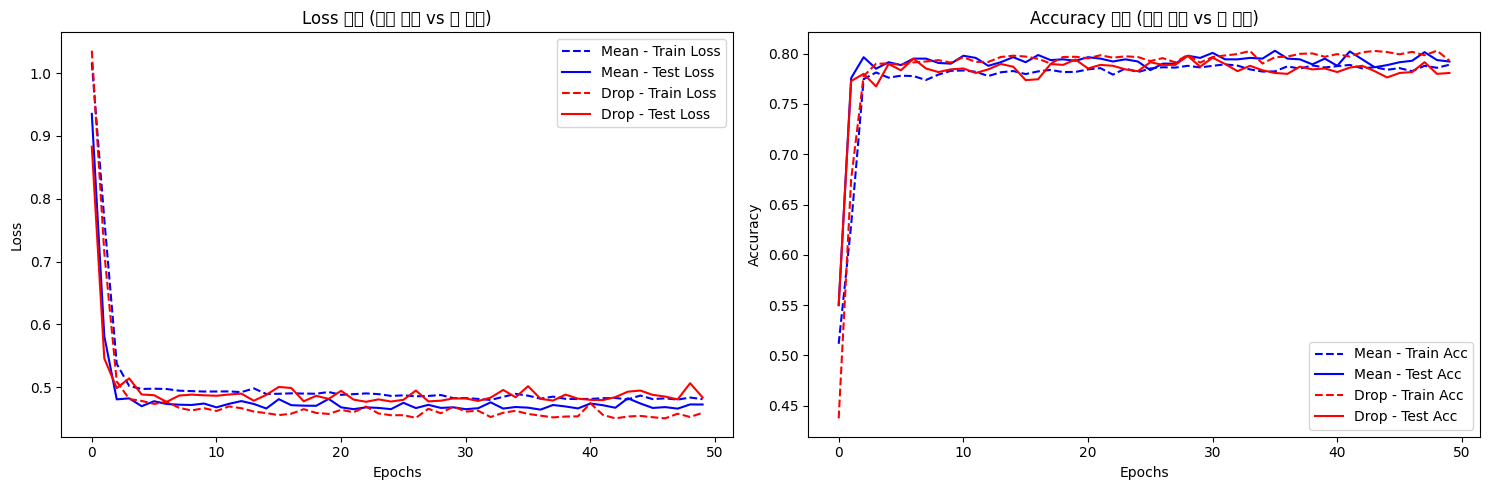

[평균 대체] Train Acc: 0.7889 | Test Acc: 0.7921
[행 제거]   Train Acc: 0.7930 | Test Acc: 0.7807


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss 비교
axes[0].plot(history_mn['train_loss'], label='Mean - Train Loss', color='blue', linestyle='--')
axes[0].plot(history_mn['test_loss'],  label='Mean - Test Loss',  color='blue')
axes[0].plot(history_dp['train_loss'], label='Drop - Train Loss', color='red',  linestyle='--')
axes[0].plot(history_dp['test_loss'],  label='Drop - Test Loss',  color='red')
axes[0].set_title('Loss 비교 (평균 대체 vs 행 제거)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy 비교
axes[1].plot(history_mn['train_acc'], label='Mean - Train Acc', color='blue', linestyle='--')
axes[1].plot(history_mn['test_acc'],  label='Mean - Test Acc',  color='blue')
axes[1].plot(history_dp['train_acc'], label='Drop - Train Acc', color='red',  linestyle='--')
axes[1].plot(history_dp['test_acc'],  label='Drop - Test Acc',  color='red')
axes[1].set_title('Accuracy 비교 (평균 대체 vs 행 제거)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"[평균 대체] Train Acc: {history_mn['train_acc'][-1]:.4f} | Test Acc: {history_mn['test_acc'][-1]:.4f}")
print(f"[행 제거]   Train Acc: {history_dp['train_acc'][-1]:.4f} | Test Acc: {history_dp['test_acc'][-1]:.4f}")

## 실험 결과

- 결측값을 평균으로 대체하는 것이 더 좋은 모델
- 행 제거 시 데이터 손실로 인해 상대적으로 미세한 과적합 발생
- → **평균 대체(fillna mean) 채택**

**최종 실험 결론 정리**

| 실험 | 결론 |
|---|---|
| Feature Selection | 전체 feature(stress_level 제외) |
| 정규화 방법 | MinMaxScaler |
| 결측치 처리 | 평균값 대체 |